In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('cars_missing_value_imputed.csv')

In [ ]:
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
df.head()

,region,price,manufacturer,model,cylinders,fuel,odometer,transmission,drive,type,seats,engine_cc,max_power,age
0,agra,512000,tata,tiago,3.00,petrol,20979,manual,fwd,hatchback,5.00,1199,84.88,5
1,agra,745000,maruti suzuki,baleno,4.00,petrol,20176,manual,fwd,hatchback,5.00,1197,81.86,3
2,agra,465000,hyundai,grand i10,3.00,cng,41448,manual,fwd,hatchback,5.00,1197,81.86,7
3,agra,546000,maruti suzuki,celerio,3.00,petrol,8527,manual,fwd,hatchback,5.00,998,67.04,3
4,agra,428000,hyundai,santro,4.00,cng,102049,manual,fwd,hatchback,5.00,1086,68.05,5


In [ ]:
df['cylinders'] = df['cylinders'].astype('int')

In [ ]:
df.head()

,region,price,manufacturer,model,cylinders,fuel,odometer,transmission,drive,type,seats,engine_cc,max_power,age
0,agra,512000,tata,tiago,3,petrol,20979,manual,fwd,hatchback,5.00,1199,84.88,5
1,agra,745000,maruti suzuki,baleno,4,petrol,20176,manual,fwd,hatchback,5.00,1197,81.86,3
2,agra,465000,hyundai,grand i10,3,cng,41448,manual,fwd,hatchback,5.00,1197,81.86,7
3,agra,546000,maruti suzuki,celerio,3,petrol,8527,manual,fwd,hatchback,5.00,998,67.04,3
4,agra,428000,hyundai,santro,4,cng,102049,manual,fwd,hatchback,5.00,1086,68.05,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58914 entries, 0 to 58913
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   region        58914 non-null  object 
 1   price         58914 non-null  float64
 2   manufacturer  58914 non-null  object 
 3   model         58914 non-null  object 
 4   cylinders     58914 non-null  int64  
 5   fuel          58914 non-null  object 
 6   odometer      58914 non-null  int64  
 7   transmission  58914 non-null  object 
 8   drive         58914 non-null  object 
 9   type          58914 non-null  object 
 10  seats         58914 non-null  float64
 11  engine_cc     58914 non-null  int64  
 12  max_power     58914 non-null  float64
 13  age           58914 non-null  int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 6.3+ MB


In [ ]:
df['price'].describe()

,price
count,57763.00
mean,711723.45
std,605726.28
min,40000.00
25%,350000.00
50%,540000.00
75%,842000.00
max,4500000.00


<Axes: xlabel='price'>

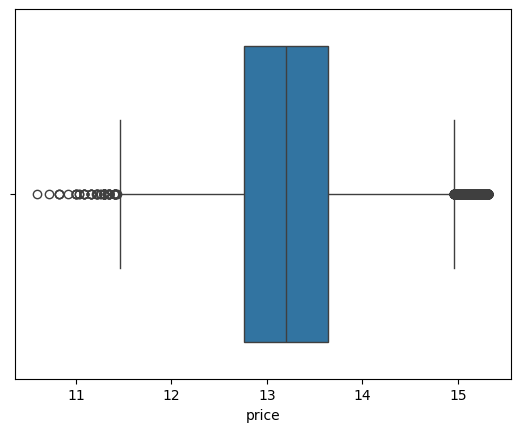

In [ ]:
sns.boxplot(np.log1p(df['price']), orient = 'h')

<Axes: xlabel='price', ylabel='Count'>

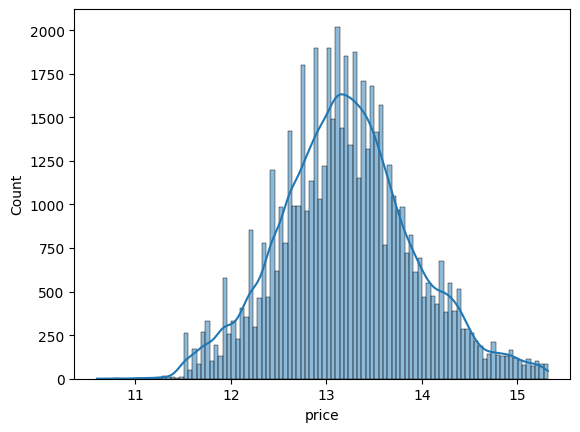

In [ ]:
sns.histplot(np.log1p(df['price']), kde = True)

In [ ]:
df['odometer'].describe()

,odometer
count,57763.00
mean,60004.11
std,48302.74
min,100.00
25%,31406.00
50%,54020.00
75%,80000.00
max,4500088.00


<Axes: xlabel='odometer', ylabel='Count'>

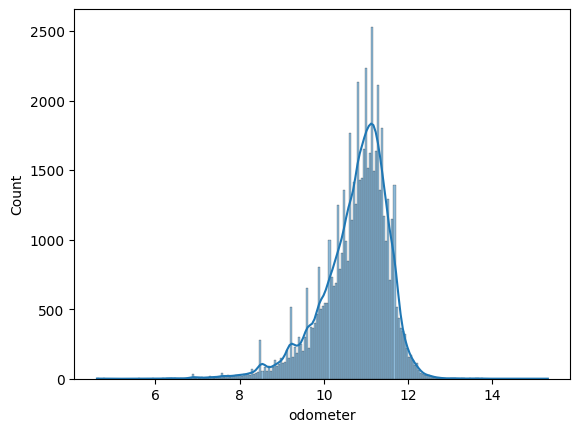

In [ ]:
sns.histplot(np.log1p(df['odometer']), kde = True)

<Axes: xlabel='odometer'>

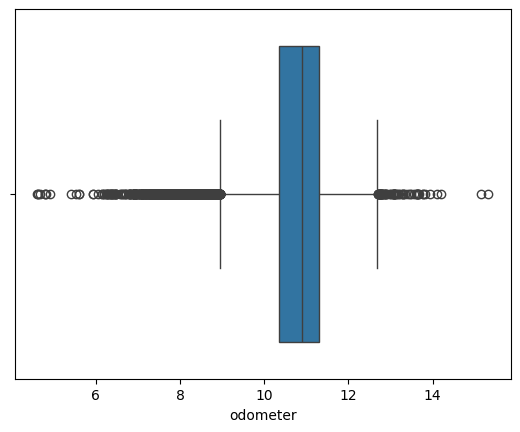

In [ ]:
sns.boxplot(np.log1p(df['odometer']), orient = 'h')

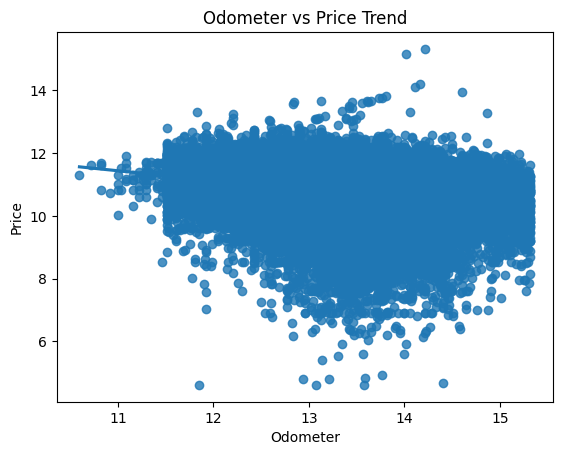

In [ ]:
sns.regplot(x = np.log1p(df['price']), y = np.log1p(df['odometer']))

plt.xlabel('Odometer')
plt.ylabel('Price')
plt.title('Odometer vs Price Trend')

plt.show()

In [ ]:
df[['odometer','price']].corr()

,odometer,price
odometer,1.00,-0.15
price,-0.15,1.00


In [ ]:
df[['cylinders', 'price']].corr()

,cylinders,price
cylinders,1.00,0.30
price,0.30,1.00


In [ ]:
df[['engine_cc', 'price']].corr()

,engine_cc,price
engine_cc,1.00,0.55
price,0.55,1.00


In [ ]:
df[['max_power', 'price']].corr()

,max_power,price
max_power,1.00,0.71
price,0.71,1.00


In [ ]:
df[['odometer', 'engine_cc']].corr()

,odometer,engine_cc
odometer,1.00,0.19
engine_cc,0.19,1.00


In [ ]:
df[['odometer', 'max_power']].corr()

,odometer,max_power
odometer,1.00,0.04
max_power,0.04,1.00


In [ ]:
df[['odometer', 'cylinders']].corr()

,odometer,cylinders
odometer,1.00,0.12
cylinders,0.12,1.00


In [ ]:
df[['cylinders', 'engine_cc']].corr()

,cylinders,engine_cc
cylinders,1.00,0.57
engine_cc,0.57,1.00


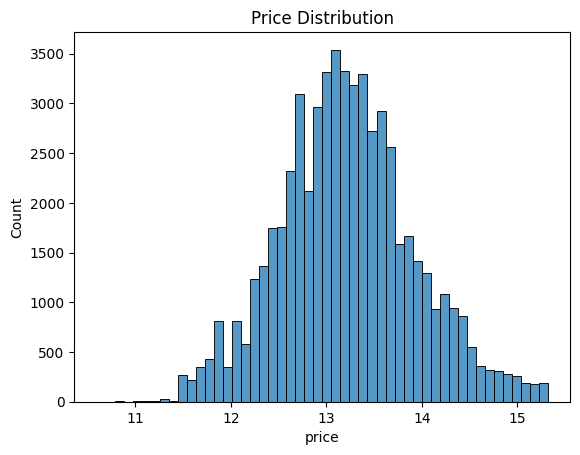

In [ ]:
sns.histplot(np.log1p(df['price']), bins=50)
plt.title("Price Distribution")
plt.show()

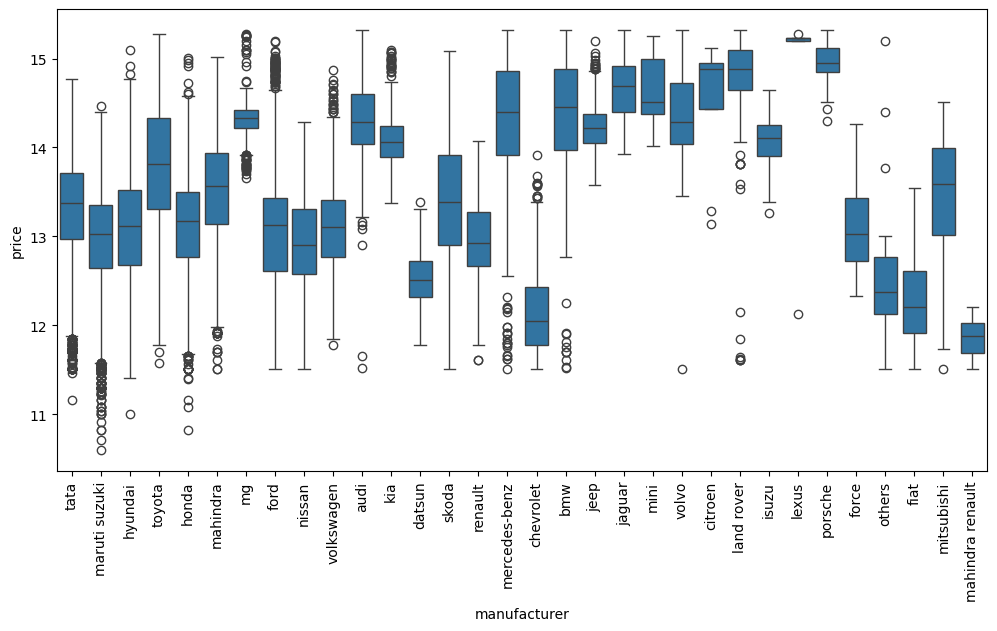

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x=df['manufacturer'], y=np.log1p(df['price']))
plt.xticks(rotation=90)
plt.show()

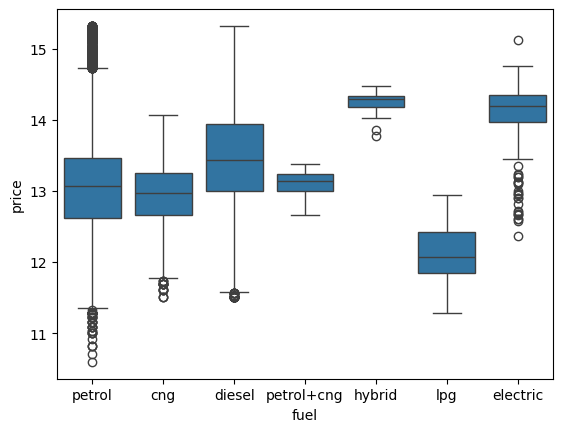

In [ ]:
sns.boxplot(x=df['fuel'], y=np.log1p(df['price']))
plt.show()

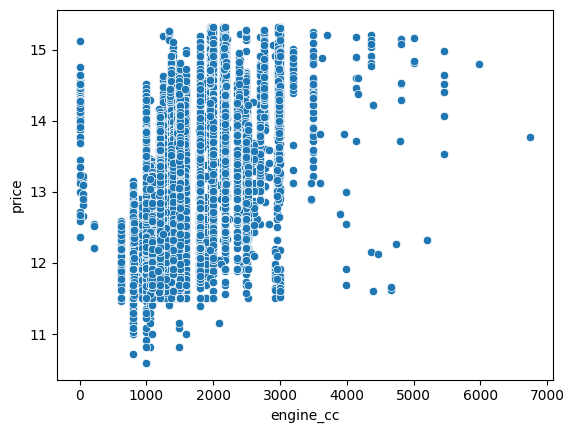

In [ ]:
sns.scatterplot(x=df['engine_cc'], y=np.log1p(df['price']))
plt.show()

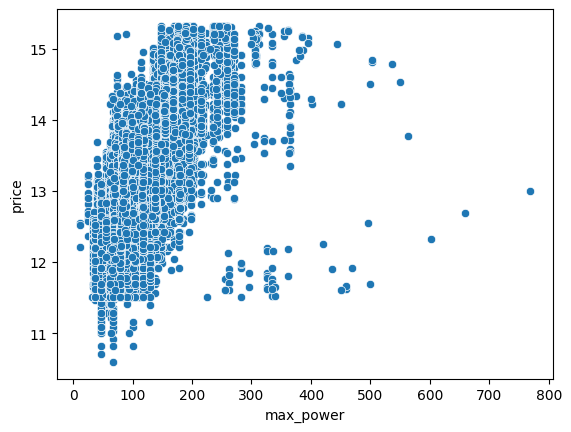

In [ ]:
sns.scatterplot(x=df['max_power'], y=np.log1p(df['price']))
plt.show()

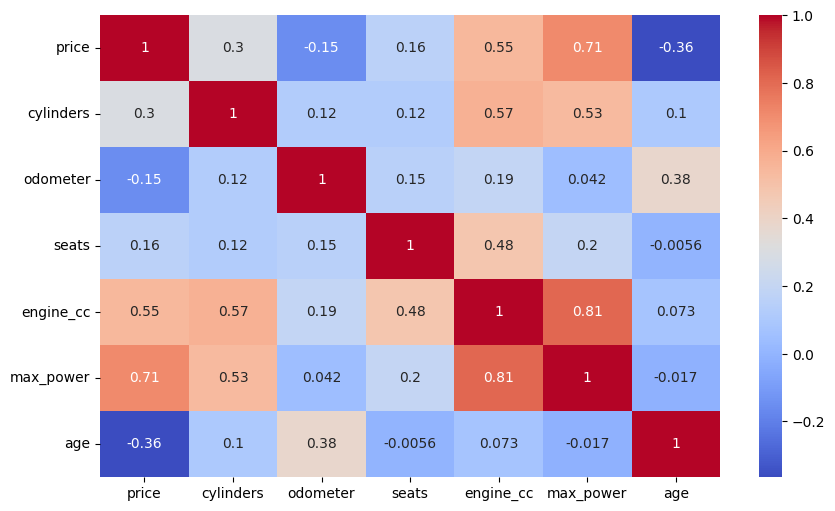

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='type', ylabel='price'>

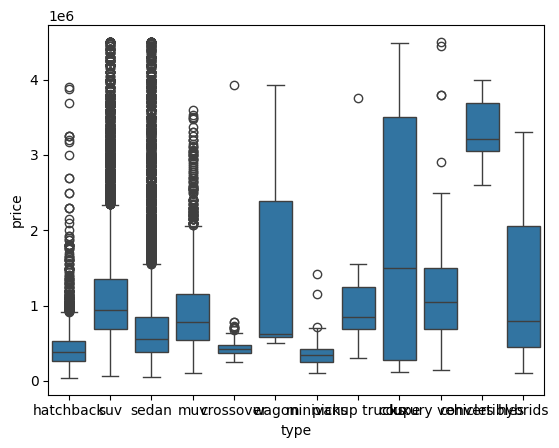

In [ ]:
sns.boxplot(x='type', y='price', data=df)

<Axes: xlabel='transmission', ylabel='price'>

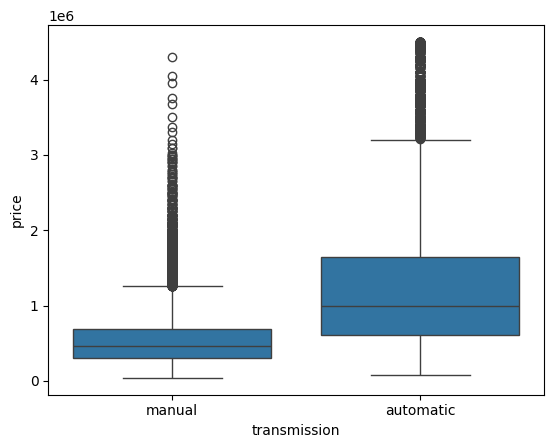

In [ ]:
sns.boxplot(x='transmission', y='price', data=df)


In [ ]:
df[df['price'] > df['price'].quantile(0.99)]

,region,price,manufacturer,model,cylinders,fuel,odometer,transmission,drive,type,seats,engine_cc,max_power,age
88,bangalore,3989358,mercedes-benz,e-class,4,petrol,17860,automatic,rwd,sedan,5.00,2143,170.00,7
125,bangalore,3726758,audi,q3,4,petrol,25545,automatic,fwd,suv,5.00,1968,174.30,4
2666,gurgaon,3928758,mini,countryman,4,petrol,11098,automatic,fwd,crossover,5.00,1248,74.02,3
2668,gurgaon,3928758,volvo,s90,4,petrol,47490,automatic,fwd,sedan,5.00,1969,190.00,2
2993,hyderabad,3726758,audi,q3,4,petrol,23389,automatic,fwd,suv,5.00,1968,174.30,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40627,new delhi,3750000,toyota,fortuner,4,diesel,60000,automatic,rwd,suv,7.00,2755,174.50,6
40647,chandigarh,3560000,ford,endeavour,4,diesel,37304,automatic,4wd,suv,7.00,1996,167.62,6
40842,new delhi,3550000,toyota,fortuner,4,diesel,31000,automatic,4wd,suv,7.00,2755,174.50,7
42113,rajkot,3700000,toyota,fortuner,4,diesel,67000,automatic,4wd,suv,7.00,2755,174.50,7


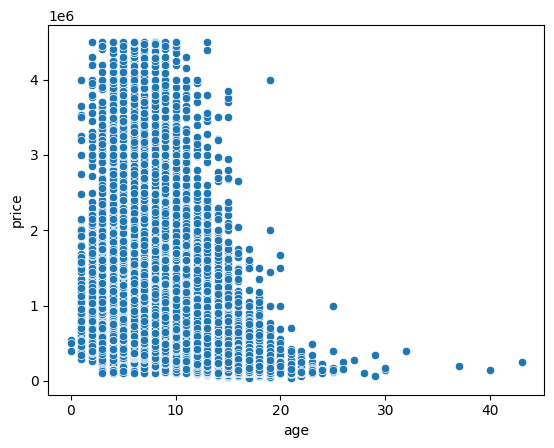

In [ ]:
sns.scatterplot(x='age', y='price', data=df)
plt.show()

In [ ]:
df.groupby('manufacturer')['price'].median().sort_values(ascending=False)

,price
manufacturer,
lexus,4100000.00
porsche,3100000.00
land rover,2900000.00
citroen,2900000.00
jaguar,2400000.00
mini,2000000.00
bmw,1900000.00
mercedes-benz,1800000.00
mg,1673000.00


In [ ]:
df.groupby('transmission')['price'].median()

,price
transmission,
automatic,1000000.00
manual,470000.00


In [ ]:
df.groupby('fuel')['price'].median()

,price
fuel,
cng,430000.00
diesel,685000.00
electric,1465000.00
hybrid,1612319.00
lpg,175000.00
petrol,475000.00
petrol+cng,506000.00


In [ ]:
df['price']

,price
0,512000
1,745000
2,465000
3,546000
4,428000
...,...
57758,881000
57759,245000
57760,735000
57761,225000


In [ ]:
np.log1p(df['price'])

,price
0,13.15
1,13.52
2,13.05
3,13.21
4,12.97
...,...
57758,13.69
57759,12.41
57760,13.51
57761,12.32


In [ ]:
df['seats'] = df['seats'].astype(int)

In [ ]:
df.head()

,region,price,manufacturer,model,cylinders,fuel,odometer,transmission,drive,type,seats,engine_cc,max_power,age
0,agra,512000,tata,tiago,3,petrol,20979,manual,fwd,hatchback,5,1199,84.88,5
1,agra,745000,maruti suzuki,baleno,4,petrol,20176,manual,fwd,hatchback,5,1197,81.86,3
2,agra,465000,hyundai,grand i10,3,cng,41448,manual,fwd,hatchback,5,1197,81.86,7
3,agra,546000,maruti suzuki,celerio,3,petrol,8527,manual,fwd,hatchback,5,998,67.04,3
4,agra,428000,hyundai,santro,4,cng,102049,manual,fwd,hatchback,5,1086,68.05,5


In [ ]:
df.to_csv('cars_data_post_eda.csv', index = False)